# Import das Bibliotecas

In [257]:
# Data Manipulation
import pandas as pd

## Data Viz
import morethemes as mt
mt.set_theme("minimal")
pd.set_option('display.max_columns', None)


import seaborn as sns
import matplotlib.pyplot as plt

# Modelos:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [258]:
df_cdk = pd.read_csv('Chronic_Kidney_Dsease_data.csv', sep = ',')

In [259]:
df_cdk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 53 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   V0         1659 non-null   int64  
 1   V1         1659 non-null   int64  
 2   V2         1659 non-null   int64  
 3   V3         1659 non-null   int64  
 4   V4         1659 non-null   int64  
 5   V5         1659 non-null   int64  
 6   V6         1659 non-null   float64
 7   V7         1659 non-null   int64  
 8   V8         1659 non-null   float64
 9   V9         1659 non-null   float64
 10  V10        1659 non-null   float64
 11  V11        1659 non-null   float64
 12  V12        1659 non-null   int64  
 13  V13        1659 non-null   int64  
 14  V14        1659 non-null   int64  
 15  V15        1659 non-null   int64  
 16  V16        1659 non-null   int64  
 17  V17        1659 non-null   int64  
 18  V18        1659 non-null   int64  
 19  V19        1659 non-null   float64
 20  V20     

In [260]:
df_cdk.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,Diagnosis
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,0
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,0
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,0
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,0
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,0


In [261]:
df_cdk.describe()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,Diagnosis
count,1659.000000,1659.000000,1659.000000,1659.00000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000
mean,830.000000,54.441230,0.515371,0.71308,0.977697,1.693189,27.620049,0.292948,9.969831,5.024247,5.028544,6.942324,0.141049,0.301386,0.257384,0.105485,0.210368,134.392405,89.313442,132.529429,6.983682,2.753198,27.578147,66.829202,2.493736,149.881615,139.968984,4.505336,9.489156,3.505543,13.927304,224.251158,125.044597,60.746861,224.804603,0.295359,0.318264,5.011715,0.380952,0.202532,0.201929,5.016697,3.482121,3.525510,5.054869,49.730659,0.044002,0.103074,0.197107,2.000336,4.947788,5.144973,0.081374
std,479.056364,20.549757,0.499914,1.00043,0.776686,0.910611,7.288670,0.455252,5.798787,2.866274,2.865777,1.704159,0.348177,0.458998,0.437325,0.307270,0.407693,25.767794,17.354479,36.563035,1.734714,1.317168,12.808062,30.050836,1.449695,86.850287,2.905595,0.583963,0.574849,0.576634,2.338372,43.666586,42.645021,23.170415,100.321757,0.456341,0.465943,2.869813,0.485767,0.402007,0.401560,2.896311,1.986292,2.026131,2.880460,27.827593,0.205162,0.304147,0.397934,1.141635,2.869959,2.901138,0.273492
min,1.000000,20.000000,0.000000,0.00000,0.000000,0.000000,15.033888,0.000000,0.021740,0.001186,0.002407,4.001053,0.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000,70.044768,4.000405,0.501799,5.000249,15.107850,0.000900,0.178427,135.006489,3.503408,8.500033,2.503727,10.004223,150.015707,50.074597,20.030993,50.267668,0.000000,0.000000,0.000469,0.000000,0.000000,0.000000,0.015194,0.005171,0.006327,0.013697,0.087256,0.000000,0.000000,0.000000,0.001082,0.005392,0.004436,0.000000
25%,415.500000,36.000000,0.000000,0.00000,0.000000,1.000000,21.471449,0.000000,5.051156,2.555038,2.558443,5.487083,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,75.000000,100.504503,5.494988,1.583255,16.398275,41.149324,1.226335,76.784343,137.483563,3.993559,9.004488,2.984834,11.839478,186.440971,87.660348,41.252078,140.235507,0.000000,0.000000,2.619890,0.000000,0.000000,0.000000,2.464695,1.750661,1.820793,2.532867,26.991708,0.000000,0.000000,0.000000,1.005802,2.498119,2.569561,0.000000
50%,830.000000,54.000000,1.000000,0.00000,1.000000,2.000000,27.652077,0.000000,9.951503,5.072395,4.989810,6.933255,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,89.000000,131.478423,6.988001,2.732006,28.077796,66.555207,2.505260,150.195312,139.863171,4.505416,9.470789,3.511712,13.909388,223.202106,126.537520,61.845056,226.466365,0.000000,0.000000,5.078511,0.000000,0.000000,0.000000,5.117247,3.519894,3.572522,5.087086,48.970075,0.000000,0.000000,0.000000,2.040635,4.974069,5.182949,0.000000
75%,1244.500000,72.000000,1.000000,1.00000,2.000000,2.000000,34.015849,1.000000,14.967100,7.460563,7.428290,8.346298,0.000000,1.000000,1.000000,0.000000,0.000000,157.000000,104.000000,163.108151,8.523562,3.889830,38.127391,92.388269,3.748696,225.057873,142.534461,5.022982,9.983515,4.009621,16.012084,262.681917,159.887298,80.388199,309.782788,1.000000,1.000000,7.485980,1.000000,0.000000,0.000000,7.565993,5.253156,5.254956,7.552093,73.913997,0.000000,0.000000,0.000000,2.947213,7.499783,7.733253,0.000000
max,1659.000000,90.000000,1.000000,3.00000,2.000000,3.000000,39.993532,1.000000,19.992713,9.998167,9.998927,9.984197,1.000000,1.000000,1.000000

In [262]:
# Mudar classe zero para 1
df_cdk['Diagnosis'].value_counts(1)*100

Diagnosis
0    91.862568
1     8.137432
Name: proportion, dtype: float64

## Analise de Distribuição dos dados

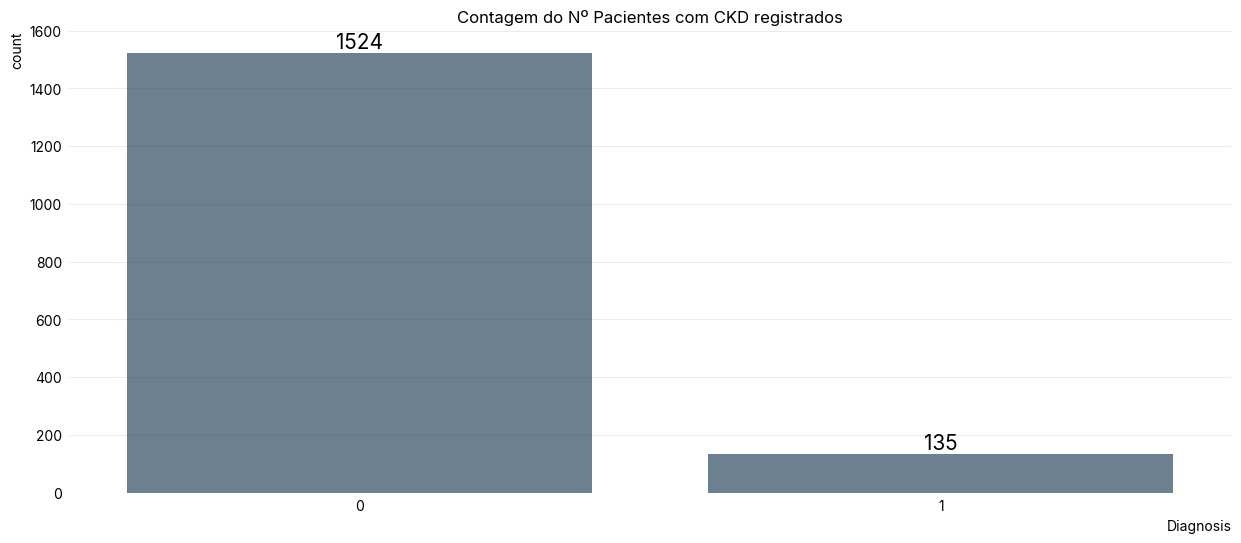

In [263]:
plt.figure(figsize = (15,6))
ax = sns.countplot(data = df_cdk, x = 'Diagnosis')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=15)
    
plt.title('Contagem do Nº Pacientes com CKD registrados')
plt.show()

## Split em treino e teste

In [264]:
x = df_cdk.drop(['Diagnosis'], axis =1)
y = df_cdk['Diagnosis']

In [265]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify= y)

# Regressão Logística

In [266]:
LR = LogisticRegression()

LR.fit(x_train, y_train)

y_pred = LR.predict(x_test)

c:\Users\degio\Downloads\2025\Preditiva\Mentorias\19 de Abril - Classificação Desbalanceada\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [267]:
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm)

,0,1
0,452,5
1,37,4


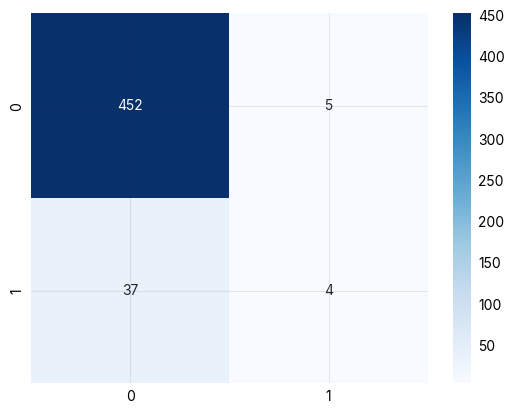

In [268]:
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [269]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96       457
           1       0.44      0.10      0.16        41

    accuracy                           0.92       498
   macro avg       0.68      0.54      0.56       498
weighted avg       0.88      0.92      0.89       498



In [270]:
print(f'Acurácia balanceada de {balanced_accuracy_score(y_test,y_pred)}')

Acurácia balanceada de 0.5433100282862785


## Predição da probabilidade para a Regressão Logística

In [271]:
LR.predict_proba(x_test)

array([[7.50592778e-01, 2.49407222e-01],
       [8.09979509e-01, 1.90020491e-01],
       [9.94710568e-01, 5.28943184e-03],
       [9.46245599e-01, 5.37544013e-02],
       [9.94682284e-01, 5.31771606e-03],
       [9.97909974e-01, 2.09002561e-03],
       [9.84624014e-01, 1.53759856e-02],
       [9.96591574e-01, 3.40842627e-03],
       [9.96454064e-01, 3.54593623e-03],
       [9.70110569e-01, 2.98894306e-02],
       [9.83488675e-01, 1.65113255e-02],
       [9.99087901e-01, 9.12099356e-04],
       [9.32461766e-01, 6.75382341e-02],
       [9.66195435e-01, 3.38045654e-02],
       [9.88787872e-01, 1.12121278e-02],
       [4.32932564e-01, 5.67067436e-01],
       [9.17402262e-01, 8.25977383e-02],
       [4.51691990e-01, 5.48308010e-01],
       [9.89271616e-01, 1.07283843e-02],
       [9.93854455e-01, 6.14554544e-03],
       [9.94847848e-01, 5.15215217e-03],
       [9.97272608e-01, 2.72739184e-03],
       [9.93202520e-01, 6.79747994e-03],
       [9.88386240e-01, 1.16137600e-02],
       [9.032743

In [272]:
y_pred_proba = LR.predict_proba(x_test)[:,1]

## Plotando a curva de Precisão vs Recall - Regressão Logistica

In [273]:
y_pred_proba = LR.predict_proba(x_test)[:,1]
precision_LR, recall_LR, thresholds_LR = precision_recall_curve(y_test, y_pred_proba)

C:\Users\degio\AppData\Local\Temp\ipykernel_28824\1449485618.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


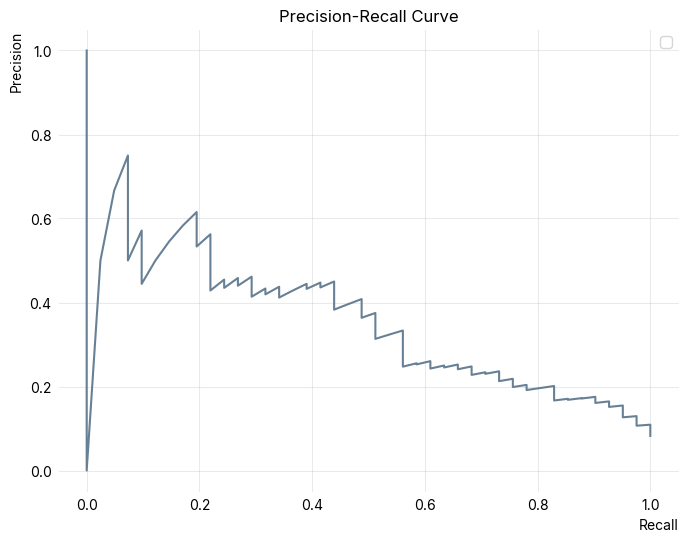

In [ ]:
def plot_precision_recall_curve(rec, prec):
    plt.figure(figsize=(8, 6))
    plt.plot(rec, prec)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_precision_recall_curve(recall_LR, precision_LR)

# Regressão Logística com class Weight

In [275]:
LR_CW = LogisticRegression(class_weight='balanced')

LR_CW.fit(x_train, y_train)

y_pred = LR_CW.predict(x_test)

c:\Users\degio\Downloads\2025\Preditiva\Mentorias\19 de Abril - Classificação Desbalanceada\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


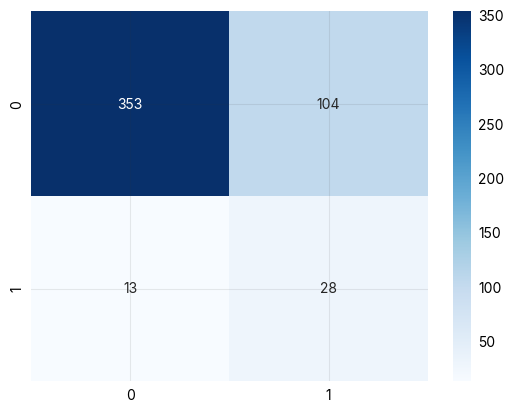

In [276]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [277]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.77      0.86       457
           1       0.21      0.68      0.32        41

    accuracy                           0.77       498
   macro avg       0.59      0.73      0.59       498
weighted avg       0.90      0.77      0.81       498



# XGBoost padrão

In [281]:
xgb = XGBClassifier()

xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

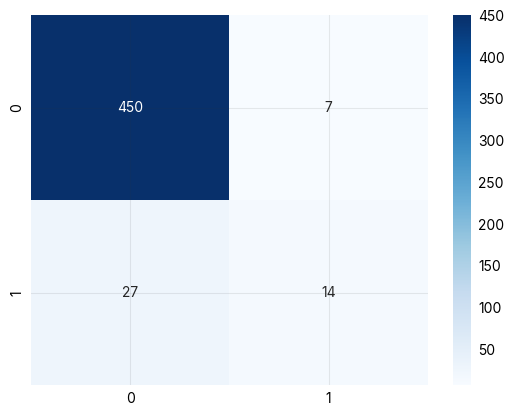

In [282]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [283]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       457
           1       0.67      0.34      0.45        41

    accuracy                           0.93       498
   macro avg       0.81      0.66      0.71       498
weighted avg       0.92      0.93      0.92       498



In [284]:
y_pred_proba = xgb.predict_proba(x_test)[:,1]
precision_xgb, recall_xgb, thresholds = precision_recall_curve(y_test, y_pred_proba)

C:\Users\degio\AppData\Local\Temp\ipykernel_28824\1449485618.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


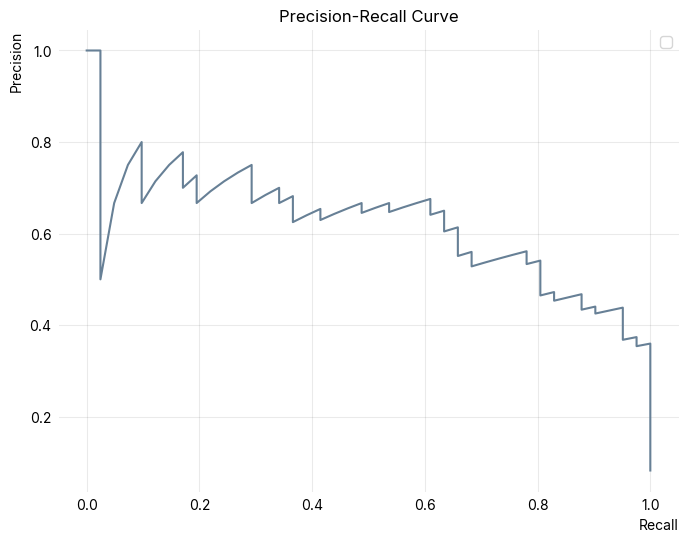

In [338]:
plot_precision_recall_curve(recall_xgb, precision_xgb)
# plot_precision_recall_curve(recall_LR, precision_LR)

## Calculando a proporção de Pesos

In [310]:
y_train.value_counts()

Diagnosis
0    1067
1      94
Name: count, dtype: int64

In [311]:
scale_pos_weight = y_train.value_counts()[0]/y_train.value_counts()[1]
scale_pos_weight

np.float64(11.351063829787234)

In [325]:
xgb_CW = XGBClassifier(scale_pos_weight = scale_pos_weight)

xgb_CW.fit(x_train, y_train)

y_pred = xgb_CW.predict(x_test)

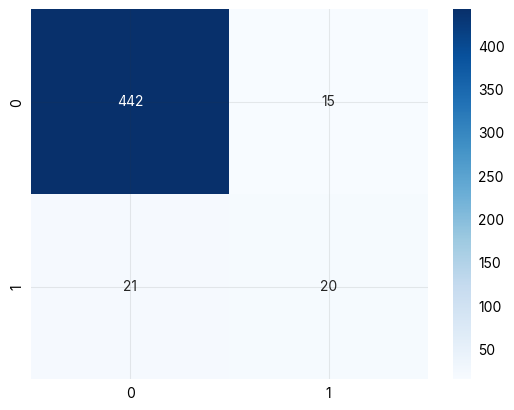

In [326]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [327]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       457
           1       0.57      0.49      0.53        41

    accuracy                           0.93       498
   macro avg       0.76      0.73      0.74       498
weighted avg       0.92      0.93      0.93       498



In [ ]:
y_pred_proba = xgb_CW.predict_proba(x_test)[:,1]
precision_xgb_CW, recall_xgb_CW, thresholds = precision_recall_curve(y_test, y_pred_proba)

In [209]:
lgbm = LGBMClassifier()

lgbm.fit(x_train, y_train)

y_pred = lgbm.predict(x_test)

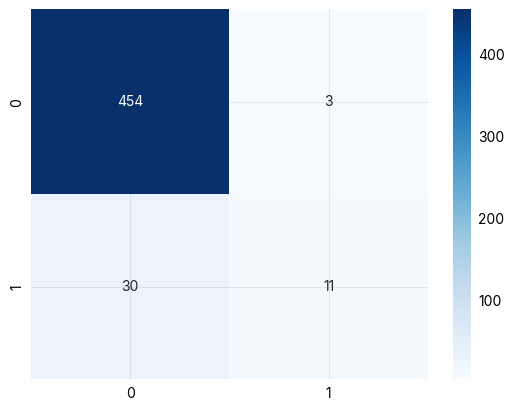

In [210]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [211]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       457
           1       0.79      0.27      0.40        41

    accuracy                           0.93       498
   macro avg       0.86      0.63      0.68       498
weighted avg       0.93      0.93      0.92       498



# LightGBM

In [331]:
lgbm = LGBMClassifier()

lgbm.fit(x_train, y_train)

y_pred = lgbm.predict(x_test)

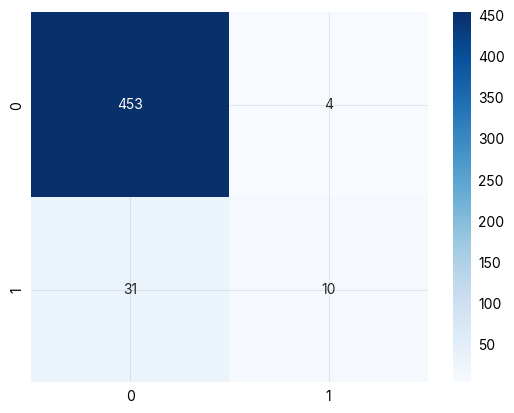

In [332]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [333]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       457
           1       0.71      0.24      0.36        41

    accuracy                           0.93       498
   macro avg       0.83      0.62      0.66       498
weighted avg       0.92      0.93      0.91       498



In [336]:
y_pred_proba = lgbm.predict_proba(x_test)[:,1]
precision_lgbm, recall_lgbm, thresholds = precision_recall_curve(y_test, y_pred_proba)

C:\Users\degio\AppData\Local\Temp\ipykernel_28824\1449485618.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


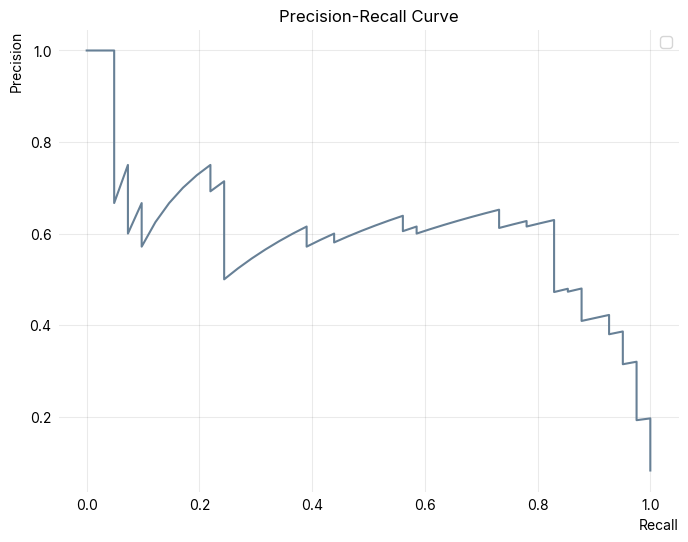

In [339]:
plot_precision_recall_curve(recall_lgbm, precision_lgbm)

## LGBM with Weight Class Balanced

In [342]:
lgbm_WC = LGBMClassifier(class_weight='balanced')

lgbm_WC.fit(x_train, y_train)

y_pred = lgbm_WC.predict(x_test)

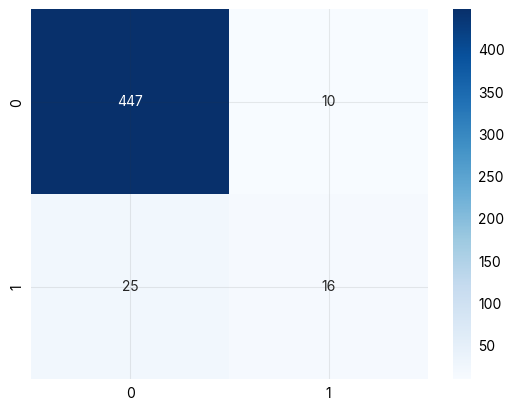

In [343]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [344]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       457
           1       0.62      0.39      0.48        41

    accuracy                           0.93       498
   macro avg       0.78      0.68      0.72       498
weighted avg       0.92      0.93      0.92       498



# Thershold selection

Vamos avaliar como a seleção de thershold pode ajudar o modelo a melhorar seu desempenho

C:\Users\degio\AppData\Local\Temp\ipykernel_28824\1449485618.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


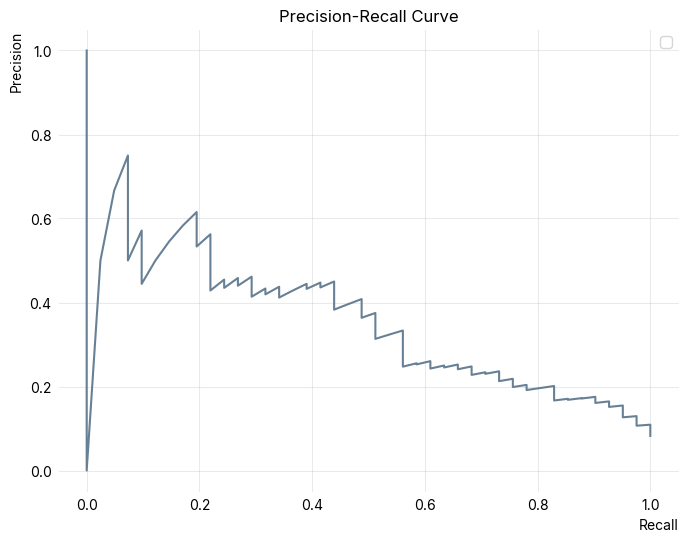

In [349]:
plot_precision_recall_curve(recall_LR, precision_LR)

## Procurando pela melhor threshold de decisão

In [365]:
tCV = TunedThresholdClassifierCV(estimator= LR)

tCV.fit(x_train, y_train)

c:\Users\degio\Downloads\2025\Preditiva\Mentorias\19 de Abril - Classificação Desbalanceada\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\degio\Downloads\2025\Preditiva\Mentorias\19 de Abril - Classificação Desbalanceada\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

TunedThresholdClassifierCV(estimator=LogisticRegression())

In [366]:
tCV.best_threshold_

np.float64(0.06973367511352602)

In [367]:
y_pred = tCV.predict(x_test)

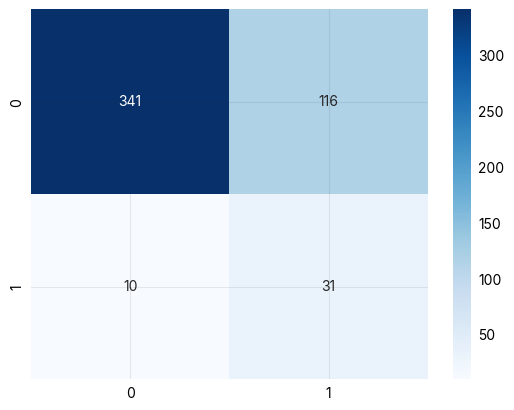

In [368]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [369]:
print(classification_report(y_test, tCV.predict(x_test)))

              precision    recall  f1-score   support

           0       0.97      0.75      0.84       457
           1       0.21      0.76      0.33        41

    accuracy                           0.75       498
   macro avg       0.59      0.75      0.59       498
weighted avg       0.91      0.75      0.80       498



## Combinando Thershold Selection e Modelos de Boosting Balanceados

In [370]:
tCV = TunedThresholdClassifierCV(estimator= lgbm_WC)

tCV.fit(x_train, y_train)

TunedThresholdClassifierCV(estimator=LGBMClassifier(class_weight='balanced'))

In [374]:
tCV.best_threshold_

np.float64(0.02015489188176029)

In [375]:
y_pred = tCV.predict(x_test)

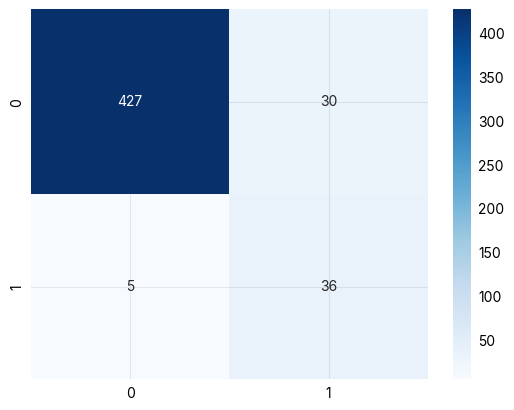

In [376]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(data = pd.DataFrame(cm), cmap='Blues', annot=True, fmt = 'g')
plt.show()

In [377]:
print(classification_report(y_test, tCV.predict(x_test)))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96       457
           1       0.55      0.88      0.67        41

    accuracy                           0.93       498
   macro avg       0.77      0.91      0.82       498
weighted avg       0.95      0.93      0.94       498

